In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [ ]:
# =============================
# Load Dataset
# =============================

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)



100%|██████████| 9.91M/9.91M [00:00<00:00, 92.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 54.8MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 40.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.25MB/s]


In [ ]:
# =============================
# Define CNN from Scratch
# =============================

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Convolution Layer 1
        # Input: 1 channel (grayscale) # In RGB - 3 channels
        # Output: 8 feature maps
        # Kernel size = 3x3
        # Stride = 1
        # Padding = 1 (keeps image same size)

        # INPUT -> (1, 28, 28)
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=8,
            kernel_size=3,
            stride=1,
            padding=1
        )
# OUTPUT IMAGE FROM CONV
# OUTPUT SIZE: (8,28,28) : INPUT SIZE FOR POOLING


        # Max Pooling 2x2
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # OUTPUT SIZE: (8,14,14): INPUT SIZE FOR FC

        # ANN: INPUT (LINEAR) -> HIDDEN -> OUTPUT
        # Fully connected layer (1 Layer of ANN)
        self.fc1 = nn.Linear(8 * 14 * 14, 10) # 10? number of classes (digit [0-9] classification problem)

    def forward(self, x):

        # Convolution
        x = self.conv1(x)

        # Activation (non-linearity)
        x = torch.relu(x)

        # Pooling
        x = self.pool(x)

        # Flatten (getting the input ready for FC)
        x = x.view(x.size(0), -1)

        # Fully connected
        x = self.fc1(x)

        return x


model = SimpleCNN()

criterion = nn.CrossEntropyLoss() # loss function
optimizer = optim.Adam(model.parameters(), lr=0.001) # what are model.parameters()? "kernel weights" how many? "8*3*3 = 72"

In [ ]:
# =============================
# Training Loop
# =============================

for epoch in range(3):
    for images, labels in train_loader:

        optimizer.zero_grad() # clears old gradients

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward() # compute gradients using backpropagation
        optimizer.step() # update weights

    print(f"Epoch {epoch+1} complete")



Epoch 1 complete
Epoch 2 complete
Epoch 3 complete


In [ ]:
# =============================
# Evaluation
# =============================

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1) # choosing the class with maximum probability (softmax)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Accuracy:", 100 * correct / total)

Accuracy: 96.95


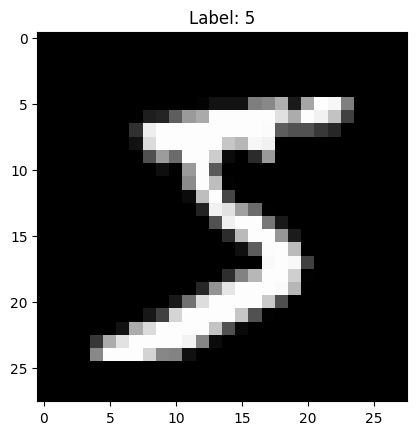

In [ ]:
# Visualize Original Image
image, label = train_dataset[0]

plt.imshow(image.squeeze(), cmap='gray') # squeeze() will make the image size compatible for matplotlib plotting
plt.title(f"Label: {label}")
plt.show()

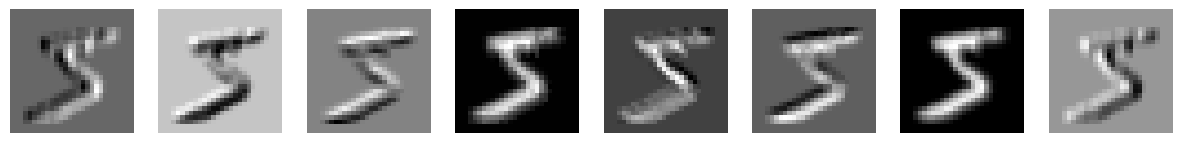

In [ ]:
# Visualize Convolution Feature Maps
with torch.no_grad():
    image = image.unsqueeze(0)  # Add batch dimension
    feature_maps = model.conv1(image) # this will give intermediate output (image) after applying the first "conv1" layer

# Plot first 8 feature maps
fig, axes = plt.subplots(1, 8, figsize=(15,5))

for i in range(8):
    axes[i].imshow(feature_maps[0][i], cmap='gray')
    axes[i].axis('off')

plt.show()

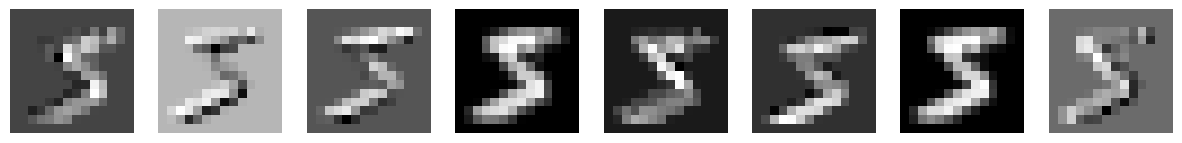

In [ ]:
# Visualize Pooling Effect
pooled = model.pool(feature_maps) # this will give intermediate output (image) after applying the second "pool" layer

fig, axes = plt.subplots(1, 8, figsize=(15,5))

for i in range(8):
    axes[i].imshow(pooled[0][i], cmap='gray')
    axes[i].axis('off')

plt.show()
'''
2 observations:
(i) the plots are smaller in size (dimension, 14x14) compared to earlier plots (28x28)
(ii) images/plots are a bit blurry because of the "pooling" (max/min/avg, etc) operation (a group of pixels get pooled/downsampled to 1 pixel, depending on the operation, and hence some amount of info is lost).
'''

Shape of Output (H, W):
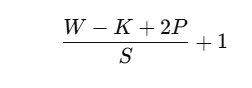

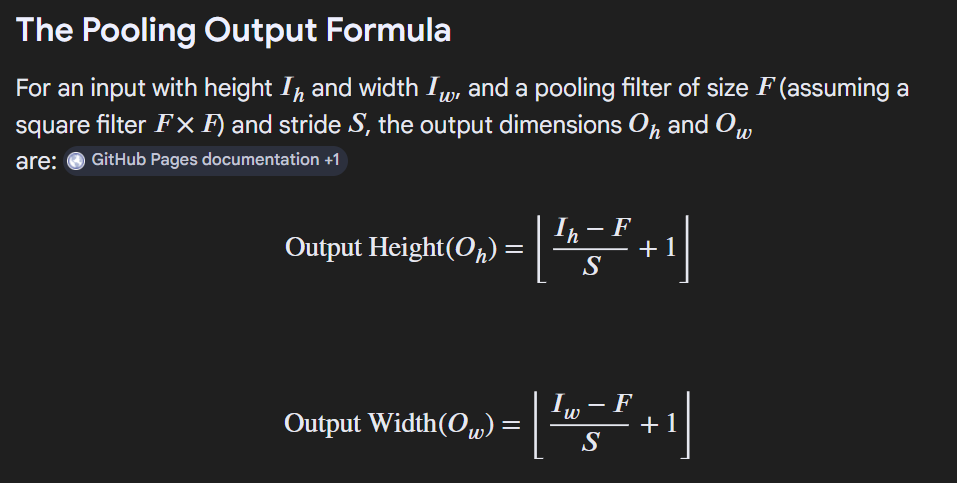